In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

In [4]:
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "05_bike_sharing_demand" / "data" / "raw"

print(PROJECT_ROOT)
print(DATA_RAW)


c:\temp\python_learning\ml_projects\ml_projects_batch_01
c:\temp\python_learning\ml_projects\ml_projects_batch_01\05_bike_sharing_demand\data\raw


In [5]:
files = sorted(DATA_RAW.iterdir())

for file in files:
    print(file.name)

sampleSubmission.csv
test.csv
train.csv


In [6]:
train = pd.read_csv(DATA_RAW / "train.csv")
test = pd.read_csv(DATA_RAW / "test.csv")
sample_submission = pd.read_csv(DATA_RAW / "sampleSubmission.csv")

In [7]:
print("train shape:", train.shape)
print("test shape:", test.shape)
print("sample submission shape:", sample_submission.shape)

train shape: (10886, 12)
test shape: (6493, 9)
sample submission shape: (6493, 2)


In [8]:
print("train columns:")
print(train.columns.tolist())

print("\ntest columns:")
print(test.columns.tolist())

print("\nsample submission columns:")
print(sample_submission.columns.tolist())

train columns:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

test columns:
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed']

sample submission columns:
['datetime', 'count']


In [10]:
important_columns = ["datetime", "casual", "registered", "count"]

for col in important_columns:
    print(f"{col}:")
    print("  in train:", col in train.columns)
    print("  in test: ", col in test.columns)
    print("\n")

datetime:
  in train: True
  in test:  True


casual:
  in train: True
  in test:  False


registered:
  in train: True
  in test:  False


count:
  in train: True
  in test:  False




In [11]:
print("Train datetime min:", train["datetime"].min())
print("Train datetime max:", train["datetime"].max())

print("\nTest datetime min:", test["datetime"].min())
print("Test datetime max:", test["datetime"].max())

Train datetime min: 2011-01-01 00:00:00
Train datetime max: 2012-12-19 23:00:00

Test datetime min: 2011-01-20 00:00:00
Test datetime max: 2012-12-31 23:00:00


In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [13]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   str    
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), str(1)
memory usage: 456.7 KB


In [14]:
print("Train missing values:")
display(train.isna().sum())

print("\nTest missing values:")
display(test.isna().sum())

Train missing values:


datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


Test missing values:


datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64

In [15]:
print("Train duplicated rows:", train.duplicated().sum())
print("Test duplicated rows:", test.duplicated().sum())

Train duplicated rows: 0
Test duplicated rows: 0


In [16]:
train["datetime"] = pd.to_datetime(train["datetime"])
test["datetime"] = pd.to_datetime(test["datetime"])

print(train["datetime"].dtype)
print(test["datetime"].dtype)

datetime64[us]
datetime64[us]


In [17]:
print("Train datetime min:", train["datetime"].min())
print("Train datetime max:", train["datetime"].max())

print("\nTest datetime min:", test["datetime"].min())
print("Test datetime max:", test["datetime"].max())

Train datetime min: 2011-01-01 00:00:00
Train datetime max: 2012-12-19 23:00:00

Test datetime min: 2011-01-20 00:00:00
Test datetime max: 2012-12-31 23:00:00


In [18]:
for df in [train, test]:
    df["year_audit"] = df["datetime"].dt.year
    df["month_audit"] = df["datetime"].dt.month
    df["day_audit"] = df["datetime"].dt.day
    df["hour_audit"] = df["datetime"].dt.hour
    df["weekday_audit"] = df["datetime"].dt.weekday

In [19]:
print("Train years:")
display(train["year_audit"].value_counts().sort_index())

print("Test years:")
display(test["year_audit"].value_counts().sort_index())

print("Train months:")
display(train["month_audit"].value_counts().sort_index())

print("Test months:")
display(test["month_audit"].value_counts().sort_index())

Train years:


year_audit
2011    5422
2012    5464
Name: count, dtype: int64

Test years:


year_audit
2011    3223
2012    3270
Name: count, dtype: int64

Train months:


month_audit
1     884
2     901
3     901
4     909
5     912
6     912
7     912
8     912
9     909
10    911
11    911
12    912
Name: count, dtype: int64

Test months:


month_audit
1     545
2     440
3     572
4     528
5     576
6     528
7     576
8     563
9     528
10    540
11    526
12    571
Name: count, dtype: int64

In [20]:
print("Train days of month:")
display(train["day_audit"].value_counts().sort_index())

print("Test days of month:")
display(test["day_audit"].value_counts().sort_index())

Train days of month:


day_audit
1     575
2     573
3     573
4     574
5     575
6     572
7     574
8     574
9     575
10    572
11    568
12    573
13    574
14    574
15    574
16    574
17    575
18    563
19    574
Name: count, dtype: int64

Test days of month:


day_audit
20    574
21    574
22    569
23    573
24    573
25    572
26    567
27    552
28    563
29    526
30    514
31    336
Name: count, dtype: int64

In [21]:
print("Train hours:")
display(train["hour_audit"].value_counts().sort_index())

print("Test hours:")
display(test["hour_audit"].value_counts().sort_index())

Train hours:


hour_audit
0     455
1     454
2     448
3     433
4     442
5     452
6     455
7     455
8     455
9     455
10    455
11    455
12    456
13    456
14    456
15    456
16    456
17    456
18    456
19    456
20    456
21    456
22    456
23    456
Name: count, dtype: int64

Test hours:


hour_audit
0     271
1     270
2     267
3     264
4     255
5     265
6     270
7     272
8     272
9     272
10    272
11    272
12    272
13    273
14    273
15    273
16    274
17    274
18    272
19    272
20    272
21    272
22    272
23    272
Name: count, dtype: int64

Базовая статистика target

In [22]:
target = "count"

train[target].describe()

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

Проверка нулей и отрицательных значений

In [23]:
print("count min:", train["count"].min())
print("count max:", train["count"].max())
print("count == 0:", (train["count"] == 0).sum())
print("count < 0:", (train["count"] < 0).sum())

count min: 1
count max: 977
count == 0: 0
count < 0: 0


Проверка скошенности target

In [24]:
print("count skew:", train["count"].skew())
print("log1p(count) skew:", np.log1p(train["count"]).skew())

count skew: 1.2420662117180776
log1p(count) skew: -0.8514116321738531


Связь casual, registered, count

In [25]:
component_check = (train["casual"] + train["registered"] == train["count"])

print("casual + registered == count for all rows:", component_check.all())
print("Rows where not equal:", (~component_check).sum())

casual + registered == count for all rows: True
Rows where not equal: 0


Корреляции target с числовыми колонками

Это audit, не feature selection. Не принимаем решений “выкинуть/оставить” только по корреляции.

In [26]:
numeric_cols = train.select_dtypes(include="number").columns.tolist()

corr_with_count = (
    train[numeric_cols]
    .corr(numeric_only=True)["count"]
    .sort_values(ascending=False)
)

corr_with_count

count            1.000000
registered       0.970948
casual           0.690414
hour_audit       0.400601
temp             0.394454
atemp            0.389784
year_audit       0.260403
month_audit      0.166862
season           0.163439
windspeed        0.101369
day_audit        0.019826
workingday       0.011594
weekday_audit   -0.002283
holiday         -0.005393
weather         -0.128655
humidity        -0.317371
Name: count, dtype: float64

Быстрые распределения target

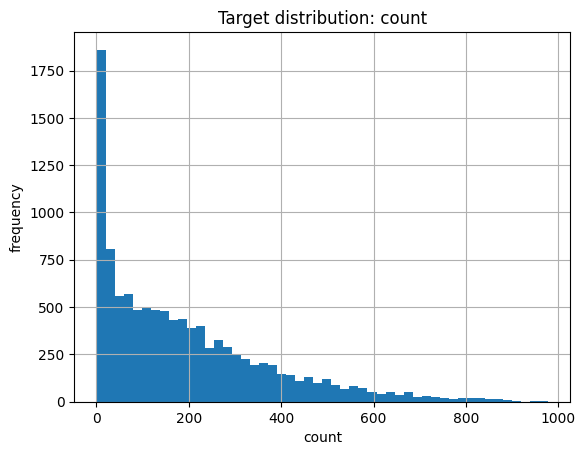

In [27]:
import matplotlib.pyplot as plt

train["count"].hist(bins=50)
plt.title("Target distribution: count")
plt.xlabel("count")
plt.ylabel("frequency")
plt.show()

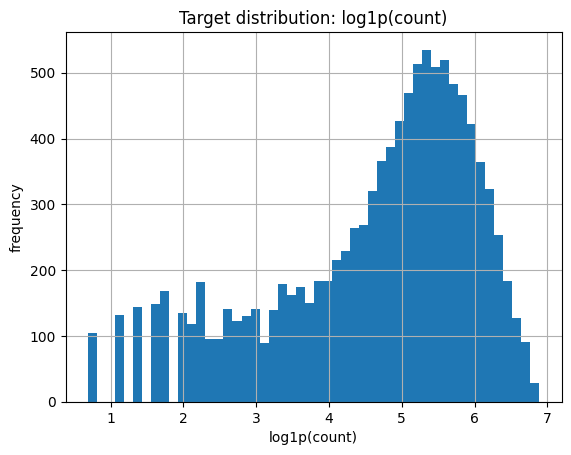

In [28]:
np.log1p(train["count"]).hist(bins=50)
plt.title("Target distribution: log1p(count)")
plt.xlabel("log1p(count)")
plt.ylabel("frequency")
plt.show()

In [29]:
train["count"].describe()

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

In [30]:
print("count min:", train["count"].min())
print("count max:", train["count"].max())
print("count == 0:", (train["count"] == 0).sum())
print("count < 0:", (train["count"] < 0).sum())

count min: 1
count max: 977
count == 0: 0
count < 0: 0


In [31]:
print("count skew:", train["count"].skew())
print("log1p(count) skew:", np.log1p(train["count"]).skew())

count skew: 1.2420662117180776
log1p(count) skew: -0.8514116321738531


In [32]:
component_check = (train["casual"] + train["registered"] == train["count"])

print("casual + registered == count for all rows:", component_check.all())
print("Rows where not equal:", (~component_check).sum())

casual + registered == count for all rows: True
Rows where not equal: 0


## Stage 0 findings: Dataset audit and task framing

### Dataset files

Raw dataset contains:

- `train.csv`
- `test.csv`
- `sampleSubmission.csv`

### Shapes

- `train.csv`: 10886 rows, 12 columns
- `test.csv`: 6493 rows, 9 columns
- `sampleSubmission.csv`: 6493 rows, 2 columns

### Target

Target column:

- `count`

The target exists in `train.csv` and does not exist in official Kaggle `test.csv`.

This means official `test.csv` must not be used for local validation. It is only for generating Kaggle submissions.

### Columns

Train columns:

- `datetime`
- `season`
- `holiday`
- `workingday`
- `weather`
- `temp`
- `atemp`
- `humidity`
- `windspeed`
- `casual`
- `registered`
- `count`

Official test columns:

- `datetime`
- `season`
- `holiday`
- `workingday`
- `weather`
- `temp`
- `atemp`
- `humidity`
- `windspeed`

### Leakage-risk columns

The columns `casual` and `registered` must not be used as model features for predicting `count`.

Reason:

```text
casual + registered == count

for all rows in train.csv.

They are components of the target, not independent predictors available at prediction time.

Datetime structure

The dataset has an hourly datetime column.

Train datetime range:

2011-01-01 00:00:00 to 2012-12-19 23:00:00

Official test datetime range:

2011-01-20 00:00:00 to 2012-12-31 23:00:00

Important split pattern:

train contains days 1–19 of each month
official test contains days 20–31 of each month

Therefore, random train/test split would be too optimistic and would not reflect the Kaggle test structure.

First task formulation

This is a supervised regression task.

Goal:

Predict hourly bike rental demand count using only features available at prediction time:

datetime-derived features
calendar features
season/weather/temperature/humidity/windspeed features

Forbidden features:

casual
registered
First local validation idea

Since official test is split by later days of each month, local validation should imitate this structure inside train.csv.

Candidate validation scheme:

train part: earlier days within each month
validation part: later available days within each month

For example:

local train: days 1–15
local validation: days 16–19

This is not perfect, because official test uses days 20–31, but it is more honest than random split.

Alternative later for CV:

time-aware split by chronological blocks
custom month/day-based validation folds

No random train_test_split should be used as the main validation scheme without explicit justification.

Metrics

Primary metric:

RMSLE, because Kaggle Bike Sharing Demand evaluates predictions using RMSLE.

Additional local metrics:

RMSE
MAE

Possible target transformation:

log1p(count) during training
inverse transform with expm1
or use TransformedTargetRegressor

This is reasonable because count is non-negative and right-skewed.

Target audit

Target count:

minimum: 1
maximum: 977
zero values: 0
negative values: 0

Skewness:

count skew: 1.2421
log1p(count) skew: -0.8514

This supports trying log-transformed target in later modeling stages.